``` py

!pip install takeHomeTest
import takeHomeTest

!pip install time
from time import oneWeek as panic

panic.dump(takeHomeTest)


print("Welcome to your take home final!\n")
```

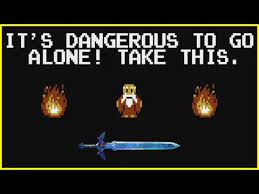




## ------------------------------------------- The Legend of Python --------------------------------------------
**Lore**

In the Kingdom of Pyrovia, all nations once traded in harmony. But since the Shattering of the Global APIs, the knowledge of currency exchange — locked away in XML scrolls — has scattered across the timelines. These scrolls reside in a mysterious repository known only as floatrates.com.

The High Council of Programmers has summoned you (and only you), young code-wielder, to begin your final trial. It is divided into 2 parts.
* Quest 1 (50xp): Retrieving the scrolls of time - Threading and Json save and parsing
* Quest 2 (50xp): Decipher the scrolls - Perform EDA on the data.

------ ------ ------ ------ Extra credit ------ ------ ------ ------ 
* Side Quest 1 (10xp*): Lay down seeds for those that follow - create error logs 
* Side Quest 2 (10xp*): The Quest of reflection  - Use profiling on your code to fully understand it 

*any points over 100% will be rolled over into your final grade. 

I may not have time to run all of your code so make sure you very clearly take notes and communicate successes, issues, and lessons learned. 
Please stay off Chat GPT and stack overflow (and like). You should have most everything you need in the notes. 

--------------------------------------------
# Quest 1 (50 xp): Retrieving the Scrolls of Time 
Retrieve historical exchange rate data from floatrates.com for one of the (Ideally randomly pick) 52 available currencies, starting from the first record on May 4, 2011, until the present day.

- You may store the data as-is in XML, or convert it to JSON, you may use the supplied code below as a starter. 

- Organize each currency into its own directory.

- Ensure your code is modular, maintainable, and robust against timeouts or malformed entries.

## Notes from the Grand Master 
* Threading is your ally. But do not burn out your ally as they have limited resources. You may use the threading or multi-core to parallelize downloads — but mind the server’s load. Around 10 threads is wise. 
    - You should have around 5040 queries.

* XML Scrolls is a new and unfamiliar beast. Therefore takeing on this beast will wield 5 extra experience points. You will not be penalized for choosing to use JSON

*  Use the Save. Nothing is worse than losing experience you have already gained. Save the raw XML (or converted JSON) using timestamped (in my example below) files so you do not need to look it up again. Ie. If you put in a start date and your program has already read that data it should not pull that date again. (it would be a good idea to delete your data and run it top to bottom before final submission)

* Design gracefully. Structure your project with clear modules: downloader.py, parser.py, and so on. 

* Log your quest progress in your quest book to show the Grand Master what you learned this is very important. 


--------------------------------------------

In [1]:
!pip install xmltodict

In [1]:
rates = ["EUR", "GBP", "USD", "DZD", "AUD", "BWP", "BND", "CAD", "CLP", "CNY", "COP", "CZK", "DKK", "HUF", "ISK", "INR", "IDR", "ILS", "KZT", "KRW", "KWD", "LYD", "MYR", "MUR", "NPR", "NZD", "NOK", "OMR", "PKR", "PLN", "QAR", "RUB", "SAR", "SGD", "ZAR", "LKR", "SEK", "CHF", "THB", "TTD"]
ratesForBase = [r for r in rates if r != "USD" and r != "EUR" and r != "GBP"]

In [6]:
import requests
import xmltodict
import json
import random

# URL of the XML data
date = "2011-05-04"
base = random.choice(ratesForBase)
url = f"https://www.floatrates.com/historical-exchange-rates.html?operation=rates&pb_id=1775&page=historical&currency_date={date}&base_currency_code={base}&format_type=xml"
print(url)
# Fetch the XML data
response = requests.get(url)
response.raise_for_status()  # Ensure we notice bad responses

# Parse the XML data to a Python dictionary
data_dict = xmltodict.parse(response.text)

# Convert the dictionary to a JSON string
json_data = json.dumps(data_dict, indent=4)

# Print the JSON data
print(json_data)

# Optionally, write the JSON data to a file
with open(f"{date}_exchange_rates_{base}.json", "w") as json_file:
    json_file.write(json_data)


https://www.floatrates.com/historical-exchange-rates.html?operation=rates&pb_id=1775&page=historical&currency_date=2011-05-04&base_currency_code=AUD&format_type=xml
{
    "channel": {
        "title": "XML Historical Foreign Exchange Rates for Australian Dollar (AUD) (4 May 2011)",
        "link": "http://www.floatrates.com/currency/aud/",
        "xmlLink": "http://www.floatrates.com/daily/aud.xml",
        "description": "XML historical foreign exchange rates for Australian Dollar (AUD) from the Float Rates. Published at 4 May 2011.",
        "language": "en",
        "baseCurrency": "AUD",
        "pubDate": "Wed, 4 May 2011",
        "lastBuildDate": "Wed, 4 May 2011",
        "item": [
            {
                "title": "1 AUD = 0.727935 EUR",
                "link": "http://www.floatrates.com/aud/eur/",
                "description": "1 Australian Dollar = 0.727935 Euro",
                "pubDate": null,
                "baseCurrency": "AUD",
                "baseName": "Aust

--------------------------------------------
# Quest 2 (50 XP): Decipher the scrolls – Exploratory Data Analysis

Once the scrolls have been retrieved their knowledge remains unrefined there patterns hidden, trends veiled. Your task now is to become the Seer of Exchange, the one who can read the currencies’ fates through the lens of data.
8
Perform Exploratory Data Analysis (EDA) on the dataset you collected in Quest 1. 
- Aggregate and visualize trends in exchange rate over time for at least 5 major currencies (e.g., USD, EUR, GBP, JPY, CNY).

- Identify periods of volatility — perhaps during economic upheaval

- Generate at least multiple visualizations using seaborn:

- Log your quest progress in your quest book to show the Grand Master what you learned this is very important. some examples of observations are:
    - Anomalies, seasonal patterns, or economic events
    - Currencies with the most/least stability
    - Any interesting correlations between currencies


## Notes from the Grand Master 
- All of your work in this section should be in your jupyter notebook. 

- It might be helpful to use  google to reveal how economic events affected currency. Use Google News or economic calendars to correlate real-world events to exchange rate spikes or dips.


--------------------------------------------


# Side Quest 1 (10 XP): Lay Down Seeds for Those Who Follow – Logging

Even the greatest explorer must leave breadcrumbs for those who walk the path after them. Here you will construct an error log system, a journal that captures both triumphs and catastrophes.

Implement a robust logging system throughout your codebase to monitor:
- Successful currency downloads
- Parsing attempts and failures
- Skipped downloads (due to saved data or time out)
- Connection errors

## Notes from the Grand Master
- You do not need to do log hierarchy 
- Use log levels: INFO for progress, WARNING for skips, ERROR for failures



--------------------------------------------


# Side Quest 2 (10 XP): The quest of Reflection – Code Profiling

The final challenge for any Adventure is introspection — learning the nature of one's own power. In this side quest, you will profile your code, to discover its bottlenecks, inefficiencies, and optimization opportunities.

Use profiling tools to evaluate:
- Which functions are taking the most time
- How threads/processes are behaving
- Whether I/O is a bottleneck

*A random vendor appears* His invintory shows:
- A Profiler function - cProfile or Profile 
- A time module - timeit for micro-benchmarks
- A line profiler - line_profiler

# Joanna Escobar

I used the code given by Mr. Powers to load the XML data and save it into a json file. I stored this code in the downloader.py file. I also knew that we had done something similar with parsing before, in the log lab (Lab 9). I copied everything I had for the parsing of the file into the parser.py file.

### Process

In working with downloader.py I started thinking that I wanted it to be the main file that all of the peripherals were called into (this later changed). It would be able to increment the date, go to the website page with information about that date, read the infromation, and download the information. The incrementation of the dates was the first problem I worked on.

#### increment_date() and related functions/variables
I had some issues directly trying to increment a string value, so I decided to iterate the date as an integer and change the integer values into strings through the increment_date() function. I would also need the downloader file to stop on today's date in order to minimize error. I did this by importing time and looking through the documentation for each of the specific functions mentioned before I was able to find a function that seemed to work. 

I realized that counting using only the increment_date() function could cause some issues and take up a lot of processing power as it was (as it would possibly need to use recursion). So, I split out the increment_date function into a different python file. There, I created the Date class to keep track of the day, month, and year so that I could iterate through them easily without needing to use recursion or any other methods that would draw too much power.

### increment_date.py

In [4]:
import time

today_str = time.strftime("%Y-%m-%d",time.gmtime()) # figured this out using the Python datasheet

# for keeping track of which months have 30 or 31 days
days_31 = [1,3,5,7,8,10,12]
days_30 = [4,6,9,11]

class Date(object):
    """Keeps track of year, month, day while allowing values to be iterated."""
    
    def __init__(self, year=2011, month=5, day=4):
        """Initializes values, defaulting to our starting day 2011-05-04."""
        self.year = year
        self.month = month
        self.day = day

    def return_date(self):
        """Turning date values into a string. Adds a zero ahead of day/month number if needed."""
        date_str = "0"
        
        if self.day < 10 and self.month >= 10:
            date_str = f"{self.year}-{self.month}-0{self.day}"
        elif self.day < 10 and self.month < 10:
            date_str = f"{self.year}-0{self.month}-0{self.day}"
        elif self.day >= 10 and self.month < 10:
            date_str = f"{self.year}-0{self.month}-{self.day}"
        else:
            date_str = f"{self.year}-{self.month}-{self.day}" 

        return date_str
    
    def increment_date(self):
        """A function to increment the date and returns date in yr-mos-day format as a string."""
        # incrementing dates depending on the month
        if self.month == 12 and self.day == 31:
            self.year += 1
            self.month = 1
            self.day = 1
        
        elif self.day == 31 and self.month in days_31:
            self.month += 1
            self.day = 1
        
        elif self.day == 30 and self.month in days_30:
            self.month += 1
            self.day = 1
        
        elif self.month == 2 and self.day == 28:
            self.month += 1
            self.day = 1
        
        else:
            self.day += 1

In [3]:
date_test = Date()

In [17]:
print(date_test.return_date())
print(f"Year: {date_test.year}")
print(f"Month: {date_test.month}")
print(f"Day: {date_test.day}")

date_test.increment_date()

2011-05-08
Year: 2011
Month: 5
Day: 8


With these two blocks of code, I showed that my functions to keep track of the dates using classes will work. I also show that I can return data in a specific written format and that the dates return as strings.

#### downloader.py contents

In [5]:
import requests
import xmltodict
import json
import random
# from increment_date import Date, today_str # importing my own files

rates = ["EUR", "GBP", "USD", "DZD", "AUD", "BWP", "BND", "CAD", "CLP", "CNY", "COP", "CZK", "DKK", "HUF", "ISK", "INR", "IDR", "ILS", "KZT", "KRW", "KWD", "LYD", "MYR", "MUR", "NPR", "NZD", "NOK", "OMR", "PKR", "PLN", "QAR", "RUB", "SAR", "SGD", "ZAR", "LKR", "SEK", "CHF", "THB", "TTD"]
ratesForBase = [r for r in rates if r != "USD" and r != "EUR" and r != "GBP"]
base = random.choice(ratesForBase)

# initializing the way days will be counted
# date = Date() # intitalizing starting values in Date 2011-05-04
# date_str = date.return_date() # chaging starting values to a string

# storing rate values in a dictionary
exc = []

def get_data(a_date_str, a_base):
    """Retreives data from floatrates.com"""
    
    # URL of thetData data
    url = f"https://www.floatrates.com/historical-exchange-rates.html?operation=rates&pb_id=1775&page=historical&currency_date={a_date_str}&base_currency_code={a_base}&format_type=xml"
    
    # Fetch the XML data
    response = requests.get(url)
    response.raise_for_status()  # Ensure we notice bad responses

    # Parse the XML data to a Python dictionary
    data_dict = xmltodict.parse(response.text)

    # Convert the dictionary to a JSON string
    json_data =  json.dumps(data_dict, indent=4)

    # Write the JSON data to a file to save raw data
    with open(f"{a_date_str}_exchange_rates_{a_base}.json", "w") as raw_data:
        raw_data.write(json_data)


    # write specific information to a new dictionary
    with open(f"{a_date_str}_exchange_rates_{a_base}.json") as file:
        json_dict = json.load(file)

    # date.increment_date()

    # # save the abbreviation of the target currency and the conversion rate to the new dict
    # for info in json_dict["channel"]["item"]:
    #     target = info["targetCurrency"]
    #     exchange = info["exchangeRate"] 
    #     # inverse = info["inverseRate"]
        
    #     exc[target] = exchange
    #     # exc_dict[f"inverse{target}"] = inverse


In running my first version of the code, I noticed that there were some type errors when I tried to iterate through the list of dictionaries in the dictionary "items" that the json data would have. I tried to solve this by keeping i an integer, but this didn't work out. I consulted the Lecture 4 notes on lists and dictionaries and also did some troubleshooting on my own.

I found out that the way I was working with it, I was returning the dictionaries within the lists as dictionaries, not as list indices. I saw a way in the notes to bypass having to use the list indicies, which was to use the dictionariy keys inside of a loop. When I implemented this, I was able to get all of the information I needed.

The `get_data()` function now works consistently and returns a dictionary with format `{Currency1:ExchangeRate1, Currency2:ExchangeRate2}`.

I also realized that for the most part, I didn't need parser, so I was able to get rid of that file. 

I had a lot of trouble with pooling the threading functions. Even when I was pooling everything, I noticed I was getting errors that mentioned Thread-189 (worker) which was way more threads than I wanted in my pool. Writing the final exchange dictionary `exc_dict` to a new file does work, but actually getting the worker working and then iterating through all the dates, without going over the pool amount has been a challenge.

I decided to make threading a new file, just to keep everything more modular and easier to work on. After that, `downloader.py` was no longer the file that everything gets run in. 

### threading_a.py

In [5]:
from increment_date import Date

#current_str = time.strftime("%Y-%m-%d",time.gmtime())
t = Date(year=2011,month=5,day=10)
t_str = t.return_date()
print(f"target date: {t_str}")


i = Date()
i_str = i.return_date()
print(f"current date: {i_str}")

dates = []

while i_str is not t_str:
    dates.append(i_str)

for date in dates:
    print(date)

target date: 2011-05-10
current date: 2011-05-04


KeyboardInterrupt: 

In [6]:
# attempt without thread pooling
import threading
# from increment_date import Date#, today_str # importing my own files
# from downloader import get_data, ratesForBase # , date_str, base, exc_dict
import time
import json

date = Date()
date_str = date.return_date()

today = Date(year=2011,month=5,day=10)
today_str = today.return_date()

threads = []
lock = threading.Lock()

while date_str <= today_str:
    for i in range(5):
        with lock:
            thread = threading.Thread(target=get_data,args=(date_str,base))
            threads.append(thread)
            thread.start()

            date.increment_date()
            date_str = date.return_date()

    for thread in threads:
        thread.join()

for thread in threads:
    print(thread)

<Thread(Thread-15 (get_data), stopped 15480)>
<Thread(Thread-16 (get_data), stopped 20764)>
<Thread(Thread-17 (get_data), stopped 14708)>
<Thread(Thread-18 (get_data), stopped 18076)>
<Thread(Thread-19 (get_data), stopped 17492)>
<Thread(Thread-20 (get_data), stopped 27728)>
<Thread(Thread-21 (get_data), stopped 18944)>
<Thread(Thread-22 (get_data), stopped 13560)>
<Thread(Thread-23 (get_data), stopped 28652)>
<Thread(Thread-24 (get_data), stopped 29440)>


In [13]:
import threading
from queue import Queue, Empty
import time
import json
from increment_date import Date, today_str # importing my own files
from downloader import get_data, date_str, base, ratesForBase #, exc_dict
    
def worker(work_queue): # taken from Mr. Power's notes
    while not work_queue.empty():
        try:
            item = work_queue.get(block=False)
        except Empty:
            break
        else:
            get_data(date_str,base)
            work_queue.task_done()

def threaded_pool(): # taken from Mr. Power's notes           
    work_queue = Queue()

    for base in ratesForBase:
        work_queue.put(base)
        threads = [
            threading.Thread(target=worker, args=(work_queue,)) 
            for _ in range(5)
        ]
    
    for thread in threads:
        thread.start()

    work_queue.join()

    while threads:    #used to delay the time output lines
        threads.pop().join

In [ ]:
while date_str <= today_str:
    threaded_pool()

print("Current active threads: "+str(threading.active_count()))

# # while date_str <= today_str:
# #     date.increment_date() # increments the yr/mo/day values in the class Date

# # Write the new dictionary to a JSON file
# exc_dict_json = json.dumps(exc_dict, indent=4)
# with open(f"{base}_exchange_rates.json", "w") as rate_dict:
#     rate_dict.write(exc_dict_json)


# scape data into a list, append list into CSV file

Exception in thread Thread-646 (worker):
Traceback (most recent call last):
  File "c:\Users\joann\anaconda3\Lib\threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "c:\Users\joann\anaconda3\Lib\threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "C:\Users\joann\AppData\Local\Temp\ipykernel_23156\4013858914.py", line 15, in worker
  File "c:\Users\joann\OneDrive\Desktop\homeworkfolder-Joanna-of-Git-Hub\TakeHome\downloader.py", line 40, in get_data
    json_dict = json.load(file)
                ^^^^^^^^^^^^^^^
  File "c:\Users\joann\anaconda3\Lib\json\__init__.py", line 293, in load
    return loads(fp.read(),
           ^^^^^^^^^^^^^^^^
  File "c:\Users\joann\anaconda3\Lib\json\__init__.py", line 346, in loads
    return _default_decoder.decode(s)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\joann\anaconda3\Lib\json\decoder.py", line 338, in decode
    obj, end = self.raw_decode(s, idx=_w(s, 0).end())
               ^^^^^^^^^

## Part 2

For this part of the Take Home final, I drew on Lab 11, where we also did Exploratory Data Analysis. I followed a very similar procedure in looking at the information.

I wasn't able to get the threading working as I wanted, but I still wanted to have some data to be able to do some form of work on. Therefore, I manually got the data from a small sample size of dates using what functions I did have working, and used this to do the analysis. I used the data for GBP, USD, EUR, JPY, and CNY as was suggested earilier in the TakeHome.

In [8]:
# importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier

import random
from increment_date import Date, today_str
from downloader import get_data, exc_dict
import json

In [9]:
selected_bases_list = ["EUR", "GBP", "USD","JPY", "CNY"]
selected_base = random.choice(selected_bases_list)
# selected_base = selected_bases_list[4]

for i in range(0,1):
    # initializing values to use to get the data
    # days<28 to keep February valid
    selected_date = Date(year=random.randint(2011,2024),month=random.randint(1,12),day=random.randint(1,28)) 
    s_date_str = selected_date.return_date()

    
    # getting data from the website
    get_data(s_date_str,selected_base)

    # writing new parsed dictionary to a new file
    found =  json.dumps(exc_dict, indent=4)

    # Write the JSON data to a file to save raw data
    with open(f"Exchange_rates_{selected_base}_to_{s_date_str}.json", "w") as w:
        w.write(found)

In [ ]:
# testing putting a json file into a CSV
with open(f"Exchange_rates_{selected_base}_to_{s_date_str}.json") as h:
    a =  json.load(h)

# ds = pd.read_csv ("student_depression_dataset.csv")
# ds_cleaned = ds.dropna()
a.to_csv("cleaned_student_depression_dataset.csv",index=False)

AttributeError: 'dict' object has no attribute 'to_csv'

Then, to keep everything tidy, I created a new CSV file myself that would have all of the exchange rates in it. I named it `{selected_base}_exchange_rates.csv` and used it hold all of the exchange rates and inverse exchange rates for any given base throughout time.

### "EUR"

In [15]:
# loading the dataset
df = pd.read_csv(f"EUR_exchange_rates.csv")
print(f"Dataset Shape:\t{df.shape}\n")
print(f"{df.head()}\n")
df.info()

Dataset Shape:	(10, 10)

         date       USD       CNY         JPY  EUR          KRW       SGD  \
0  2013-11-20  1.351250  8.247956  135.188357    1  1427.950000  1.681056   
1  2011-05-27  1.426497  9.260487  115.536132    1  1548.227306  1.764111   
2  2014-06-20  1.359851  8.437428  138.674590    1  1387.293880  1.699428   
3  2014-09-17  1.295470  7.957043  139.077335    1  1341.040635  1.636185   
4  2015-08-22  1.129549  7.221033  138.731078    1  1346.906308  1.590012   

        GBP       NZD        THB  
0  0.837432  1.621882  42.799660  
1  0.867530  1.750920  43.304551  
2  0.798190  1.562178  44.144627  
3  0.794386  1.584580  41.764036  
4  0.719618  1.700163  40.295982  

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    10 non-null     object 
 1   USD     10 non-null     float64
 2   CNY     10 non-null     float64
 3   JPY     1

In [ ]:
# Integer Encoding "date" and mapping #
eur_enc = df.dropna()


df["date"] = df["date"].astype("category")
eur_enc["date"] = df["date"].cat.codes
eur_enc["date"].unique()

e_date_mapping = dict(enumerate(df["date"].cat.categories))
print(f"date mapping: {e_date_mapping}")

In [11]:
eur_enc.corr()

,date,USD,CNY,JPY,EUR,KRW,SGD,GBP,NZD,THB
date,1.000000,-0.907806,-0.781321,0.114220,NaN,-0.751124,-0.916954,0.316462,0.086416,-0.951951
USD,-0.907806,1.000000,0.923056,-0.134323,NaN,0.747877,0.963705,0.023107,-0.096256,0.882295
CNY,-0.781321,0.923056,1.000000,-0.397869,NaN,0.822356,0.922304,0.270207,0.099956,0.718989
JPY,0.114220,-0.134323,-0.397869,1.000000,NaN,-0.290978,-0.181201,-0.405159,-0.473621,0.074421
EUR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
KRW,-0.751124,0.747877,0.822356,-0.290978,NaN,1.000000,0.756572,0.047482,0.327653,0.652507
SGD,-0.916954,0.963705,0.922304,-0.181201,NaN,0.756572,1.000000,-0.021747,0.008947,0.874094
GBP,0.316462,0.023107,0.270207,-0.405159,NaN,0.047482,-0.021747,1.000000,0.196966,-0.364035
NZD,0.086416,-0.096256,0.099956,-0.473621,NaN,0.327653,0.008947,0.196966,1.000000,-0.319837
THB,-0.951951,0.882295,0.718989,0.074421,NaN,0.652507,0.874094,-0.364035,-0.319837,1.000000


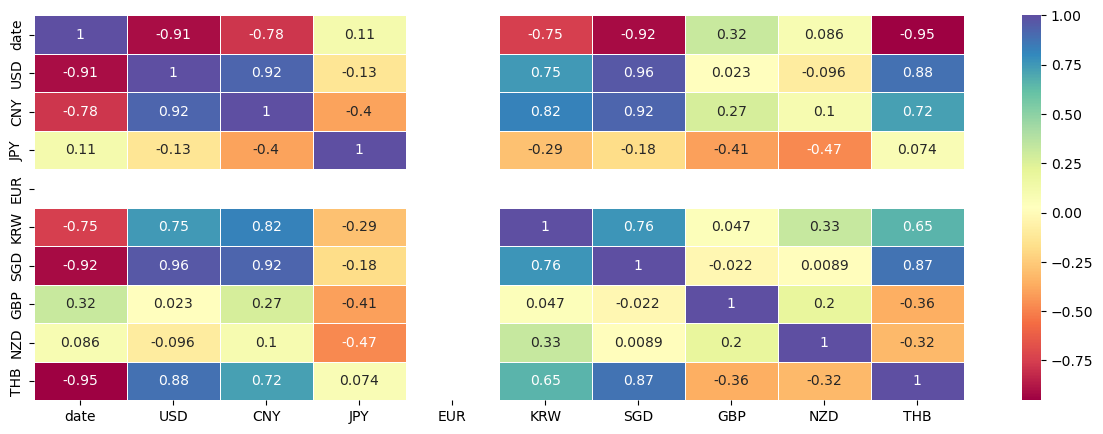

In [12]:
plt.figure(figsize = (15,5))
# wo_id = wo_id.drop(columns=['id'])
sns.heatmap(eur_enc.corr(), annot = True, linewidth = 0.5, cmap = "Spectral")
plt.show()

## "GBP"

In [ ]:
# loading the dataset
df = pd.read_csv(f"GBP_exchange_rates.csv")
print(f"Dataset Shape:\t{df.shape}\n")
print(f"{df.head()}\n")
df.info()

# replace NAs with 1

Dataset Shape:	(10, 10)

         date       USD       CNY         JPY       EUR          KRW  \
0  2013-12-14  1.629675  9.915503  168.733672  1.186788  1716.704642   
1  2014-12-04  1.568552  9.645918  187.962263  1.270756  1747.428515   
2  2017-04-17  1.254451  8.648983  136.266244  1.179588  1428.678592   
3  2017-05-14  1.286492  8.878937  146.354409  1.183234  1451.543420   
4  2017-10-15  1.329021  8.748539  148.981594  1.123608  1501.478350   

        SGD  GBP       NZD        THB  
0  2.046858    1  1.977410  52.259358  
1  2.059986    1  2.018217  51.601648  
2  1.752893    1  1.791709  43.046319  
3  1.812098    1  1.880079  44.677870  
4  1.798987    1  1.859026  43.983837  

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    10 non-null     object 
 1   USD     10 non-null     float64
 2   CNY     10 non-null     float64
 3   JPY     1

In [17]:
# Integer Encoding "date" and mapping #
gbp_enc = df.dropna()

df["date"] = df["date"].astype("category")
gbp_enc["date"] = df["date"].cat.codes
gbp_enc["date"].unique()

g_date_mapping = dict(enumerate(df["date"].cat.categories))
print(f"date mapping: {g_date_mapping}")

date mapping: {0: '2013-12-14', 1: '2014-12-04', 2: '2017-04-17', 3: '2017-05-14', 4: '2017-10-15', 5: '2018-01-28', 6: '2022-01-18', 7: '2023-11-24', 8: '2023-12-02', 9: '2024-02-01'}


In [18]:
gbp_enc.corr()

,date,USD,CNY,JPY,EUR,KRW,SGD,GBP,NZD,THB
date,1.000000,-0.684610,-0.483427,0.414069,-0.488561,0.049102,-0.805064,NaN,0.534702,-0.619585
USD,-0.684610,1.000000,0.840115,0.142286,0.544379,0.558708,0.961703,NaN,0.118933,0.928115
CNY,-0.483427,0.840115,1.000000,0.511170,0.497566,0.734853,0.739393,NaN,0.375026,0.939409
JPY,0.414069,0.142286,0.511170,1.000000,0.245158,0.846326,-0.023253,NaN,0.914438,0.376609
EUR,-0.488561,0.544379,0.497566,0.245158,1.000000,0.491605,0.652572,NaN,0.184551,0.675688
KRW,0.049102,0.558708,0.734853,0.846326,0.491605,1.000000,0.409548,NaN,0.829764,0.728716
SGD,-0.805064,0.961703,0.739393,-0.023253,0.652572,0.409548,1.000000,NaN,-0.054529,0.886722
GBP,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NZD,0.534702,0.118933,0.375026,0.914438,0.184551,0.829764,-0.054529,NaN,1.000000,0.295084
THB,-0.619585,0.928115,0.939409,0.376609,0.675688,0.728716,0.886722,NaN,0.295084,1.000000


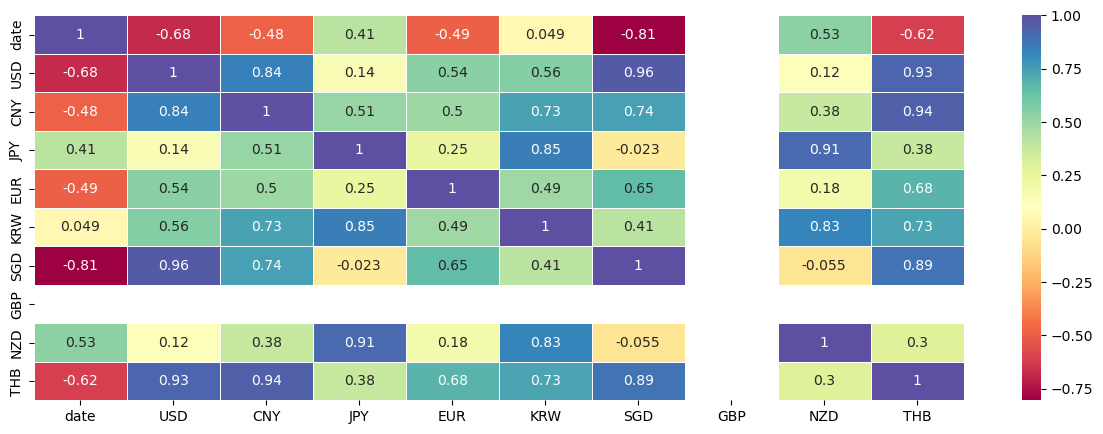

In [19]:
plt.figure(figsize = (15,5))
sns.heatmap(gbp_enc.corr(), annot = True, linewidth = 0.5, cmap = "Spectral")
plt.show()

## "USD"

In [21]:
# loading the dataset
df = pd.read_csv(f"USD_exchange_rates.csv")
print(f"Dataset Shape:\t{df.shape}\n")
print(f"{df.head()}\n")
print(f"df.info()\n")

# Integer Encoding "date" and mapping #
usd_enc = df.dropna()

df["date"] = df["date"].astype("category")
usd_enc["date"] = df["date"].cat.codes
usd_enc["date"].unique()

u_date_mapping = dict(enumerate(df["date"].cat.categories))
print(f"date mapping: {u_date_mapping}")

Dataset Shape:	(10, 10)

         date  USD       CNY         JPY       EUR          KRW       SGD  \
0  2011-05-20    1  6.495410   81.710607  0.700631  1083.578442  1.235824   
1  2015-02-11    1  6.211672  119.520209  0.884177  1099.648652  1.358347   
2  2017-08-10    1  6.657537  109.827229  0.852131  1140.950816  1.364200   
3  2019-07-20    1  6.876980  107.651809  0.889811  1176.209347  1.358170   
4  2019-12-17    1  6.997998  109.552905  0.896530  1166.635292  1.354957   

        GBP       NZD        THB  
0  0.615995  1.262118  30.274476  
1  0.655256  1.351277  32.649282  
2  0.770062  1.371941  33.249618  
3  0.798476  1.475864  30.775931  
4  0.757476  1.518023  30.235579  

df.info()

date mapping: {0: '2011-05-20', 1: '2015-02-11', 2: '2017-08-10', 3: '2019-07-20', 4: '2019-12-17', 5: '2020-05-11', 6: '2020-10-16', 7: '2023-06-09', 8: '2024-02-03', 9: '2024-11-27'}


In [22]:
gbp_enc.corr()

,date,USD,CNY,JPY,EUR,KRW,SGD,GBP,NZD,THB
date,1.000000,-0.684610,-0.483427,0.414069,-0.488561,0.049102,-0.805064,NaN,0.534702,-0.619585
USD,-0.684610,1.000000,0.840115,0.142286,0.544379,0.558708,0.961703,NaN,0.118933,0.928115
CNY,-0.483427,0.840115,1.000000,0.511170,0.497566,0.734853,0.739393,NaN,0.375026,0.939409
JPY,0.414069,0.142286,0.511170,1.000000,0.245158,0.846326,-0.023253,NaN,0.914438,0.376609
EUR,-0.488561,0.544379,0.497566,0.245158,1.000000,0.491605,0.652572,NaN,0.184551,0.675688
KRW,0.049102,0.558708,0.734853,0.846326,0.491605,1.000000,0.409548,NaN,0.829764,0.728716
SGD,-0.805064,0.961703,0.739393,-0.023253,0.652572,0.409548,1.000000,NaN,-0.054529,0.886722
GBP,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NZD,0.534702,0.118933,0.375026,0.914438,0.184551,0.829764,-0.054529,NaN,1.000000,0.295084
THB,-0.619585,0.928115,0.939409,0.376609,0.675688,0.728716,0.886722,NaN,0.295084,1.000000


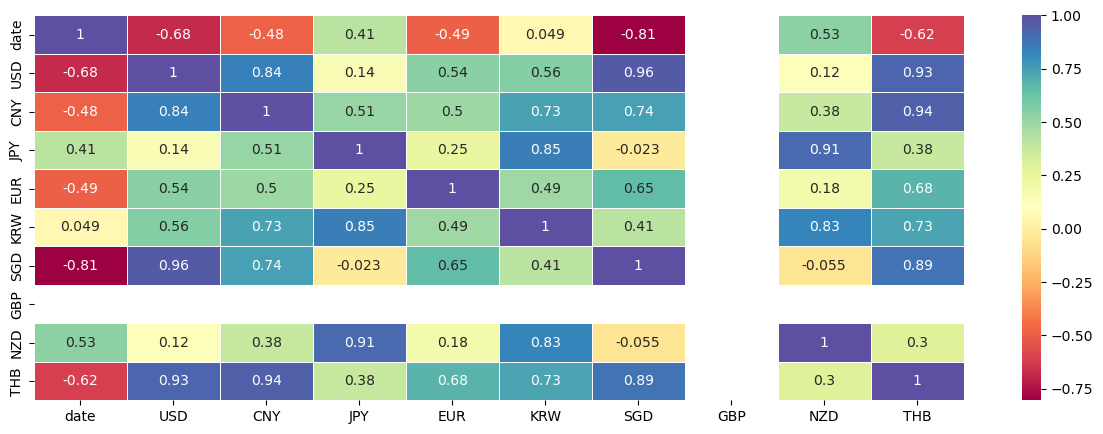

In [23]:
plt.figure(figsize = (15,5))
sns.heatmap(gbp_enc.corr(), annot = True, linewidth = 0.5, cmap = "Spectral")
plt.show()

## "JPY"

In [25]:
# loading the dataset
df = pd.read_csv(f"JPY_exchange_rates.csv")
print(f"Dataset Shape:\t{df.shape}\n")
print(f"{df.head()}\n")
print(f"df.info()\n")

# Integer Encoding "date" and mapping #
jpy_enc = df.dropna()

df["date"] = df["date"].astype("category")
jpy_enc["date"] = df["date"].cat.codes
jpy_enc["date"].unique()

j_date_mapping = dict(enumerate(df["date"].cat.categories))
print(f"date mapping: {j_date_mapping}")

Dataset Shape:	(10, 10)

         date       USD       CNY  JPY       EUR        KRW       SGD  \
0  2011-09-06  0.012972  0.082909    1  0.009230  13.926543  0.015688   
1  2013-04-26  0.010159  0.062788    1  0.007807  11.300545  0.012569   
2  2015-12-16  0.008200  0.053028    1  0.007505   9.663597  0.011539   
3  2016-06-28  0.009784  0.064985    1  0.008840  11.471898  0.013253   
4  2016-11-05  0.009706  0.065594    1  0.008741  11.086660  0.013433   

        GBP       NZD       THB  
0  0.008085  0.015685  0.388254  
1  0.006570  0.011940  0.297612  
2  0.005458  0.012122  0.294982  
3  0.007340  0.013878  0.344934  
4  0.007771  0.013266  0.339379  

df.info()

date mapping: {0: '2011-09-06', 1: '2013-04-26', 2: '2015-12-16', 3: '2016-06-28', 4: '2016-11-05', 5: '2017-12-06', 6: '2019-12-06', 7: '2022-01-17', 8: '2022-07-20', 9: '2022-11-04'}


In [26]:
jpy_enc.corr()

,date,USD,CNY,JPY,EUR,KRW,SGD,GBP,NZD,THB
date,1.000000,-0.809643,-0.722062,NaN,-0.660103,-0.693524,-0.792941,-0.441345,-0.508503,-0.762312
USD,-0.809643,1.000000,0.973728,NaN,0.870311,0.953206,0.973623,0.811700,0.845227,0.895871
CNY,-0.722062,0.973728,1.000000,NaN,0.919051,0.957643,0.971921,0.889076,0.914075,0.887625
JPY,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EUR,-0.660103,0.870311,0.919051,NaN,1.000000,0.872782,0.944169,0.907420,0.892937,0.915329
KRW,-0.693524,0.953206,0.957643,NaN,0.872782,1.000000,0.916856,0.833443,0.852611,0.876845
SGD,-0.792941,0.973623,0.971921,NaN,0.944169,0.916856,1.000000,0.856257,0.890176,0.934112
GBP,-0.441345,0.811700,0.889076,NaN,0.907420,0.833443,0.856257,1.000000,0.841368,0.821249
NZD,-0.508503,0.845227,0.914075,NaN,0.892937,0.852611,0.890176,0.841368,1.000000,0.817265
THB,-0.762312,0.895871,0.887625,NaN,0.915329,0.876845,0.934112,0.821249,0.817265,1.000000


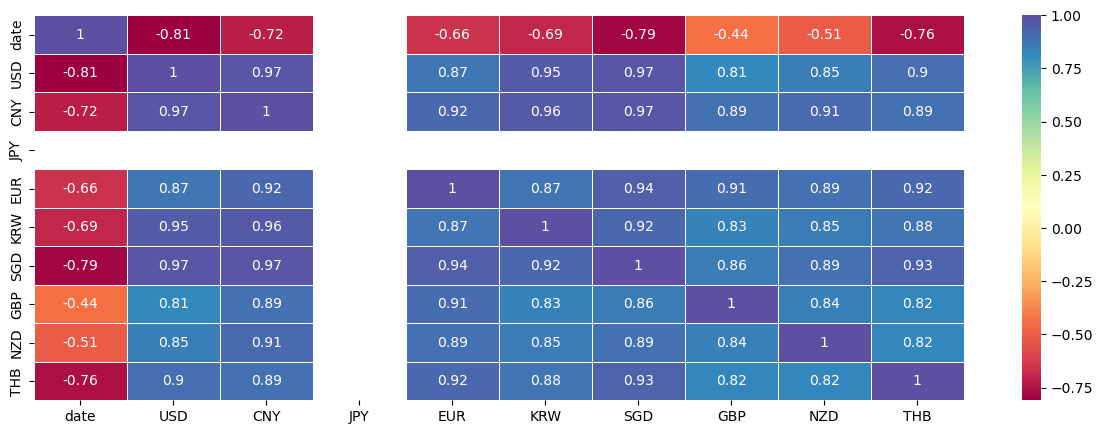

In [27]:
plt.figure(figsize = (15,5))
sns.heatmap(jpy_enc.corr(), annot = True, linewidth = 0.5, cmap = "Spectral")
plt.show()

## "CNY"

In [29]:
# loading the dataset
df = pd.read_csv(f"CNY_exchange_rates.csv")
print(f"Dataset Shape:\t{df.shape}\n")
print(f"{df.head()}\n")
print(f"df.info()\n")

# Integer Encoding "date" and mapping #
cny_enc = df.dropna()

df["date"] = df["date"].astype("category")
cny_enc["date"] = df["date"].cat.codes
cny_enc["date"].unique()

c_date_mapping = dict(enumerate(df["date"].cat.categories))
print(f"date mapping: {c_date_mapping}")

Dataset Shape:	(10, 10)

         date       USD  CNY        JPY       EUR         KRW       SGD  \
0  2012-04-06  0.158549    1  13.042237  0.121115  179.081050  0.199540   
1  2012-05-23  0.158151    1  12.577593  0.125046  185.054634  0.201915   
2  2016-09-12  0.149809    1  15.314753  0.133350  166.058009  0.203281   
3  2016-12-09  0.144818    1  16.606995  0.136823  169.066276  0.206744   
4  2017-06-24  0.146229    1  16.273178  0.130846  166.431267  0.202961   

        GBP       NZD       THB  
0  0.100031  0.194262  4.914803  
1  0.100538  0.210141  4.981534  
2  0.112741  0.204427  5.223858  
3  0.115011  0.202239  5.166250  
4  0.114920  0.200992  4.965124  

df.info()

date mapping: {0: '2012-04-06', 1: '2012-05-23', 2: '2016-09-12', 3: '2016-12-09', 4: '2017-06-24', 5: '2018-01-25', 6: '2018-03-26', 7: '2018-04-09', 8: '2023-05-04', 9: '2024-07-28'}


In [30]:
cny_enc.corr()

,date,USD,CNY,JPY,EUR,KRW,SGD,GBP,NZD,THB
date,1.000000,-0.427023,NaN,0.928670,0.186548,0.323739,-0.403771,0.491935,0.892872,-0.321846
USD,-0.427023,1.000000,NaN,-0.670030,-0.496738,-0.346747,0.679004,-0.382183,-0.363418,-0.287085
CNY,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
JPY,0.928670,-0.670030,NaN,1.000000,0.325042,0.313418,-0.532114,0.541206,0.809997,-0.112073
EUR,0.186548,-0.496738,NaN,0.325042,1.000000,-0.397406,0.230723,0.842821,0.009270,0.702740
KRW,0.323739,-0.346747,NaN,0.313418,-0.397406,1.000000,-0.840433,-0.427841,0.613499,-0.441941
SGD,-0.403771,0.679004,NaN,-0.532114,0.230723,-0.840433,1.000000,0.232210,-0.566679,0.236489
GBP,0.491935,-0.382183,NaN,0.541206,0.842821,-0.427841,0.232210,1.000000,0.203480,0.306224
NZD,0.892872,-0.363418,NaN,0.809997,0.009270,0.613499,-0.566679,0.203480,1.000000,-0.330727
THB,-0.321846,-0.287085,NaN,-0.112073,0.702740,-0.441941,0.236489,0.306224,-0.330727,1.000000


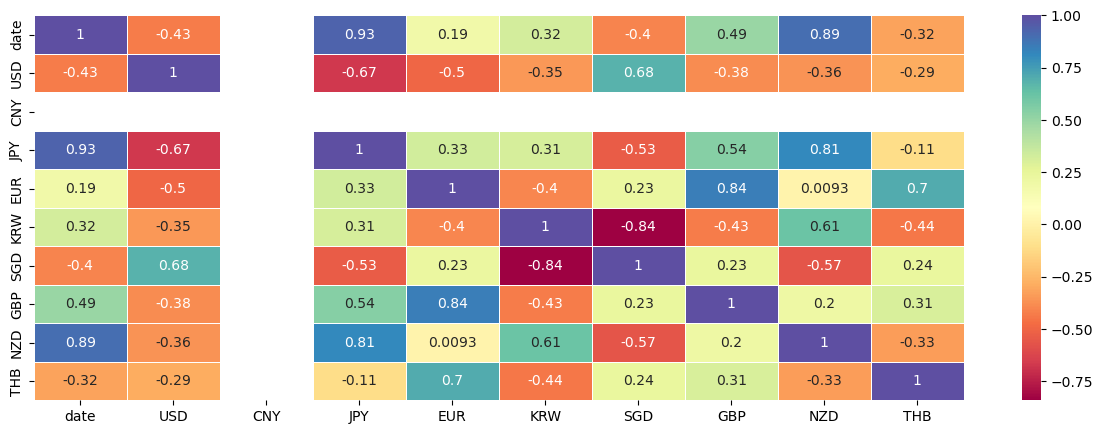

In [31]:
plt.figure(figsize = (15,5))
sns.heatmap(cny_enc.corr(), annot = True, linewidth = 0.5, cmap = "Spectral")
plt.show()